In [81]:
import numpy as np
from matplotlib import pyplot as plt
import pickle
import os, sys
import torch
from matplotlib.lines import Line2D
from collections import defaultdict
from matplotlib.colors import LinearSegmentedColormap
# Root project
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../.."))

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added to sys.path:", project_root)

from envs import *
from basal_ganglia import *
from stn_gpe import *

# filter warnings
import warnings
warnings.filterwarnings("ignore")
from tqdm.autonotebook import tqdm


plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # Times for publication
    "font.size": 8,                    # Base font size
    "axes.labelsize": 8,              # Axis label font size
    "axes.labelweight": "bold",
    "font.weight": "bold",   
    "axes.titlesize":8,              # Axis title (not fig title)
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize":8,              # Legend font size

    "figure.dpi": 300,                 # Display resolution
    "savefig.dpi": 300,                # Save resolution
    "figure.constrained_layout.use": True,  # Better spacing than tight_layout

    "axes.linewidth": 0.8,             # Thin but clear axes lines
    "lines.linewidth": 1.2,
    "lines.markersize": 5,

    "axes.spines.top": False,
    "axes.spines.right": False,

    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,

    "legend.frameon": False,
    "legend.handlelength": 2.0,        # Slightly longer legend lines
    "legend.handletextpad": 0.5,

    "pdf.fonttype": 42,                # Embed editable fonts in PDF
    "ps.fonttype": 42
})



Project root added to sys.path: d:\charitha\projects\STN-GPe_spiking\light_house_DBS_decision_making


In [ ]:
DEL_LIM_ARR = [0.1, 0.2, 0.5, 1.0] #0.01, 0.05,
VAR_ARR = [0.25,0.01, 0.04, 0.39] # Normal, PD, STD DBS, Sector DBS

In [83]:
# ENV params
NUM_ARMS = 4
MEAN_REWARD = np.array([40,40,60,80])
REW_STD = np.array([4,4,4,4])
SCALING_FACTOR = 100

# Training params
TRAILS = 300
EPOCHS = 25
BINS = 10
LR = 1e-1 


LAMBDA_DECAY = 0.9836
THETA = 50
DIFFUSIVE_NOISE_MEAN = 0
DIFFUSIVE_NOISE_STD = 2.8

In [84]:
ARM_MONITOR = defaultdict(dict)
NUM_ARM_PICKS_MONITOR = defaultdict(dict)
DP_MONITOR = defaultdict(dict)
IP_MONITOR = defaultdict(dict)
REWARD_MONITOR = defaultdict(dict)
ARM_TRACKER = defaultdict(dict)
OPTIMAL_CHOICE_MONITOR = defaultdict(dict)
ACTUAL_CHOICE_MONITOR = defaultdict(dict)
PROB_OPTIMAL_MONITOR = defaultdict(dict)
MEAN_PROB_MONITOR = defaultdict(dict)

In [85]:
env = RestlessBanditsEnv(num_arms=NUM_ARMS, 
                         mean_reward=MEAN_REWARD/SCALING_FACTOR, 
                         std = REW_STD/SCALING_FACTOR,
                         lambda_decay = LAMBDA_DECAY, 
                         theta = THETA/SCALING_FACTOR, 
                         diffusive_noise_std = DIFFUSIVE_NOISE_STD/SCALING_FACTOR, 
                         diffusive_noise_mean = DIFFUSIVE_NOISE_MEAN/SCALING_FACTOR)
print(env.arms)

{0: (0.4, 0.04), 1: (0.4, 0.04), 2: (0.6, 0.04), 3: (0.8, 0.04)}


In [86]:
# Calculate average Prob of best arm picking every bin
def max_rew_arm(x:dict):
    rew_list = np.array([x[key][0] for key in list(x.keys())])
    return np.argmax(rew_list)

def process_epoch_optimal_arm(x:list):
    optimal_arm = [max_rew_arm(x[trail]) for trail in range(len(x)-1)]
    return optimal_arm

In [87]:
for var in tqdm(VAR_ARR):
    for del_lim in DEL_LIM_ARR:
        # print(f'Running for del lim = {del_lim} and var = {var}')
        reward_monitor, arm_chosen_monitor, avg_counts,ip_monitor, dp_monitor,ep_monitor, arm_tracker_full= train(env, 
                                                      trails = TRAILS, 
                                                      epochs = EPOCHS, 
                                                      lr = LR, 
                                                      bins = BINS,
                                                      STN_data = None, #'rossler',
                                                      d1_amp=1,
                                                      d2_amp=0.01,#0.3, 
                                                      gpi_threshold=0.3,
                                                      max_gpi_iters=50,
                                                      del_lim=del_lim, train_IP = False, 
                                                      del_med = None, printing = False,
                                                      gpi_mean= 1, ep_0 = var,
                                                      alpha_ep = 0.0,
                                                      eta_ep = 0.1,
                                                      baseline_ep = 0.0, 
                                                      track_arms = True)
        
        

        ARM_MONITOR[var][del_lim] = arm_chosen_monitor
        REWARD_MONITOR[var][del_lim] = reward_monitor
        DP_MONITOR[var][del_lim] = dp_monitor
        IP_MONITOR[var][del_lim] = ip_monitor
        ARM_TRACKER[var][del_lim] = arm_tracker_full


        OPTIMAL_CHOICE_ARRAY = np.array([process_epoch_optimal_arm(ARM_TRACKER[var][del_lim][epoch]) for epoch in range(len(ARM_TRACKER[var][del_lim]))])
        ACTUAL_CHOICE_ARRAY = np.array(ARM_MONITOR[var][del_lim])
        NUMBER_OF_MATCHES = (OPTIMAL_CHOICE_ARRAY == ACTUAL_CHOICE_ARRAY)*1
        PROB = np.mean(NUMBER_OF_MATCHES,axis = 1)
        mean_prob = np.mean(PROB)


        OPTIMAL_CHOICE_MONITOR[var][del_lim] = OPTIMAL_CHOICE_ARRAY
        ACTUAL_CHOICE_MONITOR[var][del_lim] = ACTUAL_CHOICE_ARRAY
        PROB_OPTIMAL_MONITOR[var][del_lim] = PROB
        MEAN_PROB_MONITOR[var][del_lim] = mean_prob
        print(f'del_lim = {del_lim} and var = {var}: mean prob of optimal arm = {mean_prob}')




  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

del_lim = 0.1 and var = 0.25: mean prob of optimal arm = 0.4806666666666667


  0%|          | 0/25 [00:00<?, ?it/s]

del_lim = 0.2 and var = 0.25: mean prob of optimal arm = 0.5378666666666667


...

del_lim = 0.2 and var = 0.39: mean prob of optimal arm = 0.5634666666666667


  0%|          | 0/25 [00:00<?, ?it/s]

del_lim = 0.5 and var = 0.39: mean prob of optimal arm = 0.6014666666666667


  0%|          | 0/25 [00:00<?, ?it/s]

del_lim = 1.0 and var = 0.39: mean prob of optimal arm = 0.6350666666666667


In [ ]:
DEL_LIM_ARR_FILTERED = DEL_LIM_ARR
var = {'normal': VAR_ARR[0], 'PD': VAR_ARR[1], 'std_DBS': VAR_ARR[2], 'sector_DBS': VAR_ARR[3]}
Mean_Probs_PD = [MEAN_PROB_MONITOR[var['PD']][del_lim] for del_lim in DEL_LIM_ARR_FILTERED]
Mean_Probs_std_DBS = [MEAN_PROB_MONITOR[var['std_DBS']][del_lim] for del_lim in DEL_LIM_ARR_FILTERED]
Mean_Probs_sector_DBS = [MEAN_PROB_MONITOR[var['sector_DBS']][del_lim] for del_lim in DEL_LIM_ARR_FILTERED]

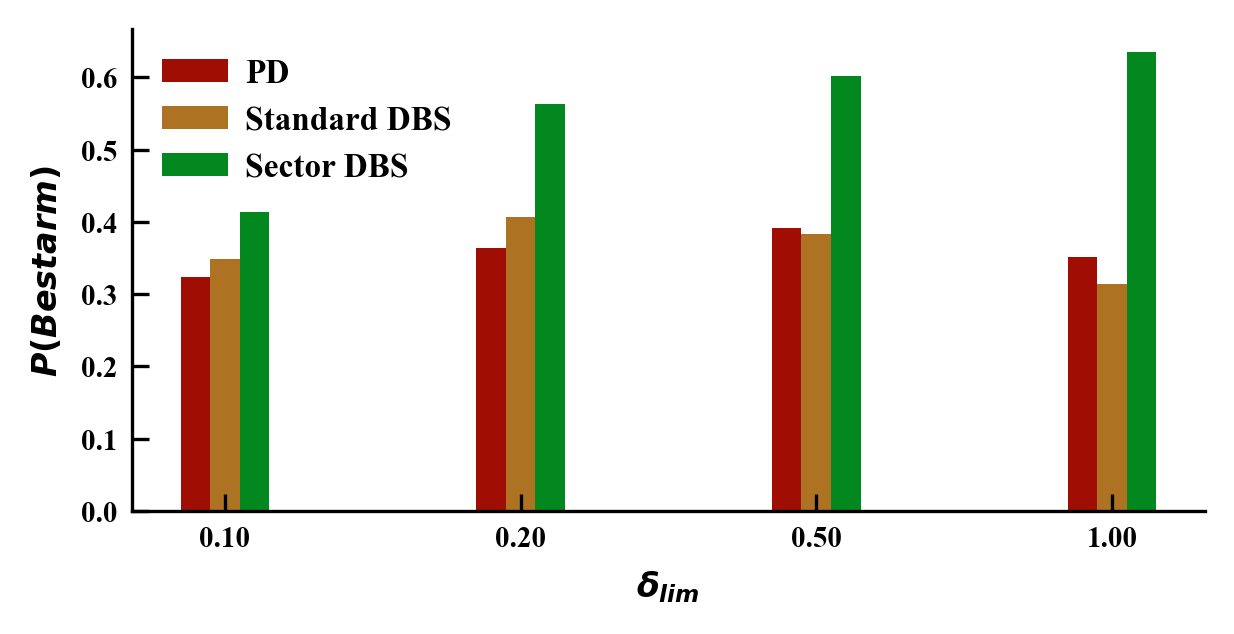

In [94]:
# plotting bar plot for each del lim on x axis and prob on y axis. Different colors for each var
bar_width = 0.1
x_values = np.arange(len(DEL_LIM_ARR_FILTERED))
alpha = 1

colors = {'normal':"#054b7c",
          'PD': "#9f0d03ce",
          'std_DBS': "#ad7322",
          'sector_DBS': "#038820",}



plt.figure(figsize=(4,2))
plt.bar(x_values - bar_width, Mean_Probs_PD, width=bar_width, label="PD", alpha=alpha, color=colors['PD'], capsize=4)
plt.bar(x_values, Mean_Probs_std_DBS, width=bar_width, label="Standard DBS", alpha=alpha, color=colors['std_DBS'], capsize=4)
plt.bar(x_values + bar_width, Mean_Probs_sector_DBS, width=bar_width, label="Sector DBS", alpha=alpha, color = colors['sector_DBS'], capsize=4)
plt.legend()
plt.xticks(x_values, [f"{v:.2f}" for v in DEL_LIM_ARR], rotation=0)
plt.xlabel('$\delta_{lim}$')
plt.ylabel('$P(Best arm)$')
plt.show()